In [1]:
import sys
sys.path.append("../")

import numpy as np
import torch
import matplotlib.pyplot as plt
from data_loader import PairData
from env_v2_01 import PairTradingEnv
from ddqn import DoubleDQN

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
random_state = np.random.RandomState(SEED)
import random; random.seed(SEED)


In [2]:
# ── Data & calibration ────────────────────────────────────────────────────
data   = PairData("../../data/real_pair_MCD_YUM.csv")
prices = data.s          # shape (2, N)
N      = prices.shape[1]

train_end   = 3 * N // 4
episode_len = N // 4     # 1/4 of total == 1/3 of train
past_window = 60

print(f"N={N}  |  train [0, {train_end})  |  test [{train_end}, {N})")
print(f"episode_len={episode_len}  |  test_len={N - train_end}")

# OLS beta on training data
log_s0_tr = np.log(prices[0, :train_end])
log_s1_tr = np.log(prices[1, :train_end])
beta      = float(np.polyfit(log_s1_tr, log_s0_tr, 1)[0])
spread_tr = log_s0_tr - beta * log_s1_tr
intercept = float(spread_tr.mean())
fixed_std = float(spread_tr.std())

print(f"beta={beta:.4f}  intercept={intercept:.4f}  fixed_std={fixed_std:.4f}")


N=5032  |  train [0, 3774)  |  test [3774, 5032)
episode_len=1258  |  test_len=1258
beta=0.9830  intercept=0.6916  fixed_std=0.1112


In [3]:
# ── Environments ─────────────────────────────────────────────────────────
env_kw = dict(beta=beta, intercept=intercept, fixed_std=fixed_std, past_window=past_window)

# Training: random window of episode_len from first 3/4
train_env = PairTradingEnv(
    prices=prices, **env_kw,
    train_end=train_end, episode_len=episode_len,
)

# Eval: full test set (include past_window lookback from training)
test_prices = prices[:, train_end - past_window:]
eval_env = PairTradingEnv(
    prices=test_prices, **env_kw,
    # train_end defaults to N_test; episode_len defaults to N_test - past_window
)

print("Train env:", train_env.observation_space)
print(f"Eval episode length: {eval_env.episode_len} steps")


Train env: Box(-inf, inf, (8,), float32)
Eval episode length: 1258 steps


In [4]:
agent = DoubleDQN(
    state_dim=8,
    action_dim=3,
    hidden=64,
    lr=3e-4,
    gamma=0.99,
    tau=0.005,
    buffer_size=int(1e6),
    batch_size=256,
    exp_noise=0.2,
)


In [5]:
# ── Training loop ────────────────────────────────────────────────────────
N_EPISODES = 1000
LOG_EVERY  = 100
TRAIN_FREQ = 4    # update every 4 env steps (reduces PyTorch CPU overhead)

ep_rewards = []
ep_wealth  = []
total_steps = 0

for ep in range(N_EPISODES):
    obs, _ = train_env.reset()
    done = False
    ep_r = 0.0

    while not done:
        action = agent.select_action(obs)
        next_obs, reward, terminated, truncated, _ = train_env.step(action)
        done = terminated or truncated
        agent.replay_buffer.add(obs, action, reward, next_obs, done)
        if total_steps % TRAIN_FREQ == 0:
            agent.train()
        obs = next_obs
        ep_r += reward
        total_steps += 1

    ep_rewards.append(ep_r)
    ep_wealth.append(train_env._wealth())

    if (ep + 1) % LOG_EVERY == 0:
        avg_r = np.mean(ep_rewards[-LOG_EVERY:])
        avg_w = np.mean(ep_wealth[-LOG_EVERY:])
        print(f"Ep {ep+1:4d} | avg_reward={avg_r:8.2f} | avg_wealth={avg_w:8.2f}")


Ep  100 | avg_reward= 7126.05 | avg_wealth=17126.05
Ep  200 | avg_reward=11765.81 | avg_wealth=21765.81
Ep  300 | avg_reward=14343.70 | avg_wealth=24343.70
Ep  400 | avg_reward=17123.70 | avg_wealth=27123.70
Ep  500 | avg_reward=19150.18 | avg_wealth=29150.18
Ep  600 | avg_reward=20739.66 | avg_wealth=30739.66
Ep  700 | avg_reward=25975.12 | avg_wealth=35975.12
Ep  800 | avg_reward=27982.03 | avg_wealth=37982.03
Ep  900 | avg_reward=28854.53 | avg_wealth=38854.53
Ep 1000 | avg_reward=30585.13 | avg_wealth=40585.13


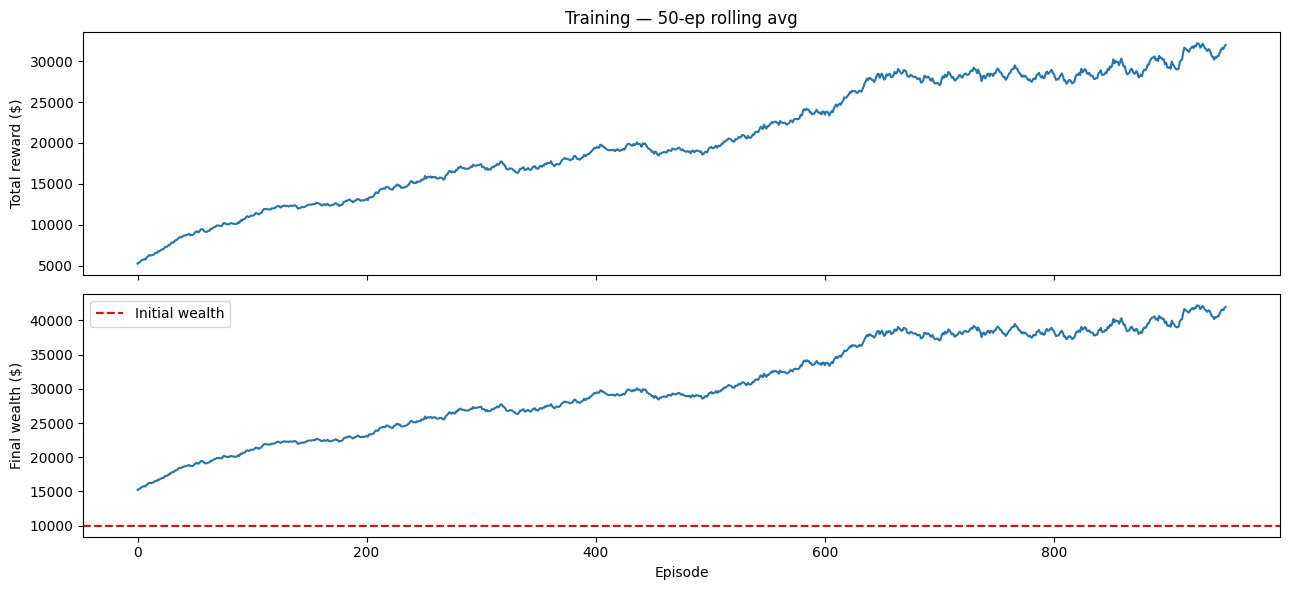

In [6]:
# ── Training curves ──────────────────────────────────────────────────────
roll = 50
kern = np.ones(roll) / roll
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
ax1.plot(np.convolve(ep_rewards, kern, mode="valid"))
ax1.set_ylabel("Total reward ($)")
ax1.set_title(f"Training — {roll}-ep rolling avg")
ax2.plot(np.convolve(ep_wealth, kern, mode="valid"))
ax2.axhline(10_000, color="r", ls="--", label="Initial wealth")
ax2.set_ylabel("Final wealth ($)")
ax2.set_xlabel("Episode")
ax2.legend()
plt.tight_layout()
plt.show()


In [11]:
# Position values: +1 = long spread, -1 = short spread, 0 = flat
_POS_LABEL = {1: "long", -1: "short", 0: "flat"}

def evaluate(env, agent):
    obs, _ = env.reset()
    done = False

    wealth  = [env._wealth()]
    s0_hist = [env.prices[0, env._t]]
    s1_hist = [env.prices[1, env._t]]
    z_hist  = [float(obs[0])]
    sp_hist = [float(env._spread[env._t])]
    pos_hist = []          # position held during each step
    entries_long  = []
    entries_short = []
    exits         = []
    step = 0

    while not done:
        prev_pos = env._pos
        action   = agent.select_action(obs, deterministic=True)
        obs, _, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        wealth.append(env._wealth())
        s0_hist.append(env.prices[0, env._safe_t()])
        s1_hist.append(env.prices[1, env._safe_t()])
        z_hist.append(float(obs[0]))
        sp_hist.append(float(env._spread[env._safe_t()]))
        pos_hist.append(prev_pos)

        if env._pos != prev_pos:
            if env._pos == 1:
                entries_long.append(step)
            elif env._pos == -1:
                entries_short.append(step)
            if env._pos == 0:
                exits.append(step)
        step += 1

    return dict(
        wealth        = np.array(wealth),
        s0            = np.array(s0_hist),
        s1            = np.array(s1_hist),
        zscores       = np.array(z_hist),
        spreads       = np.array(sp_hist),
        pos_hist      = np.array(pos_hist),
        entries_long  = entries_long,
        entries_short = entries_short,
        exits         = exits,
    )


def plot_results(res, title=""):
    wealth  = res["wealth"]
    s0, s1  = res["s0"], res["s1"]
    zscores = res["zscores"]
    spreads = res["spreads"]
    eL, eS, ex = res["entries_long"], res["entries_short"], res["exits"]

    bench = wealth[0] * (1 + 0.05/252) ** np.arange(len(wealth))

    fig, axes = plt.subplots(4, 1, figsize=(14, 16), sharex=True)

    axes[0].plot(wealth, label="DDQN")
    axes[0].plot(bench, color="gray", ls="--", lw=1, label="5% p.a.")
    axes[0].set_title(f"Portfolio value  {title}")
    axes[0].set_ylabel("Value ($)"); axes[0].legend()

    axes[1].plot(s0, label="MCD"); axes[1].plot(s1, label="YUM")
    if eL: axes[1].scatter(eL, s0[eL], color="green",  zorder=5, s=14, label="enter long")
    if eS: axes[1].scatter(eS, s0[eS], color="red",    zorder=5, s=14, label="enter short")
    if ex: axes[1].scatter(ex, s0[ex], color="blue",   zorder=5, s=14, label="exit")
    axes[1].set_title("Stock prices"); axes[1].set_ylabel("Price ($)"); axes[1].legend()

    axes[2].plot(zscores)
    for lvl, col in [(2.0,"green"),(-2.0,"green"),(0.5,"orange"),(-0.5,"orange"),(0,"gray")]:
        axes[2].axhline(lvl, color=col, lw=0.8, ls="--")
    if eL: axes[2].scatter(eL, zscores[eL], color="green", zorder=5, s=14, label="enter long")
    if eS: axes[2].scatter(eS, zscores[eS], color="red",   zorder=5, s=14, label="enter short")
    if ex: axes[2].scatter(ex, zscores[ex], color="blue",  zorder=5, s=14, label="exit")
    axes[2].set_title("Z-score"); axes[2].set_ylabel("Z-score"); axes[2].legend()

    axes[3].plot(spreads)
    axes[3].axhline(0, color="gray", lw=0.8, ls="--")
    if eL: axes[3].scatter(eL, spreads[eL], color="green", zorder=5, s=14, label="enter long")
    if eS: axes[3].scatter(eS, spreads[eS], color="red",   zorder=5, s=14, label="enter short")
    if ex: axes[3].scatter(ex, spreads[ex], color="blue",  zorder=5, s=14, label="exit")
    axes[3].set_title("Raw spread"); axes[3].set_ylabel("Spread")
    axes[3].set_xlabel("Step"); axes[3].legend()

    plt.tight_layout(); plt.show()


def metrics(wealth, label, rf_annual=0.05):
    n       = len(wealth)
    rets    = np.diff(wealth) / wealth[:-1]
    excess  = rets - rf_annual / 252
    sharpe  = excess.mean() / (excess.std() + 1e-12) * np.sqrt(252)
    hwm     = np.maximum.accumulate(wealth)
    max_dd  = ((wealth - hwm) / hwm).min()
    tot_ret = (wealth[-1] - wealth[0]) / wealth[0]
    ann_ret = (1 + tot_ret) ** (252 / n) - 1
    print(f"{label}")
    print(f"  Sharpe:            {sharpe:.3f}")
    print(f"  Max drawdown:      {max_dd*100:.2f}%")
    print(f"  Annualised return: {ann_ret*100:.2f}%")
    print(f"  Total return:      {tot_ret*100:.2f}%")
    print()
    return dict(sharpe=sharpe, max_dd=max_dd, ann_ret=ann_ret, tot_ret=tot_ret)


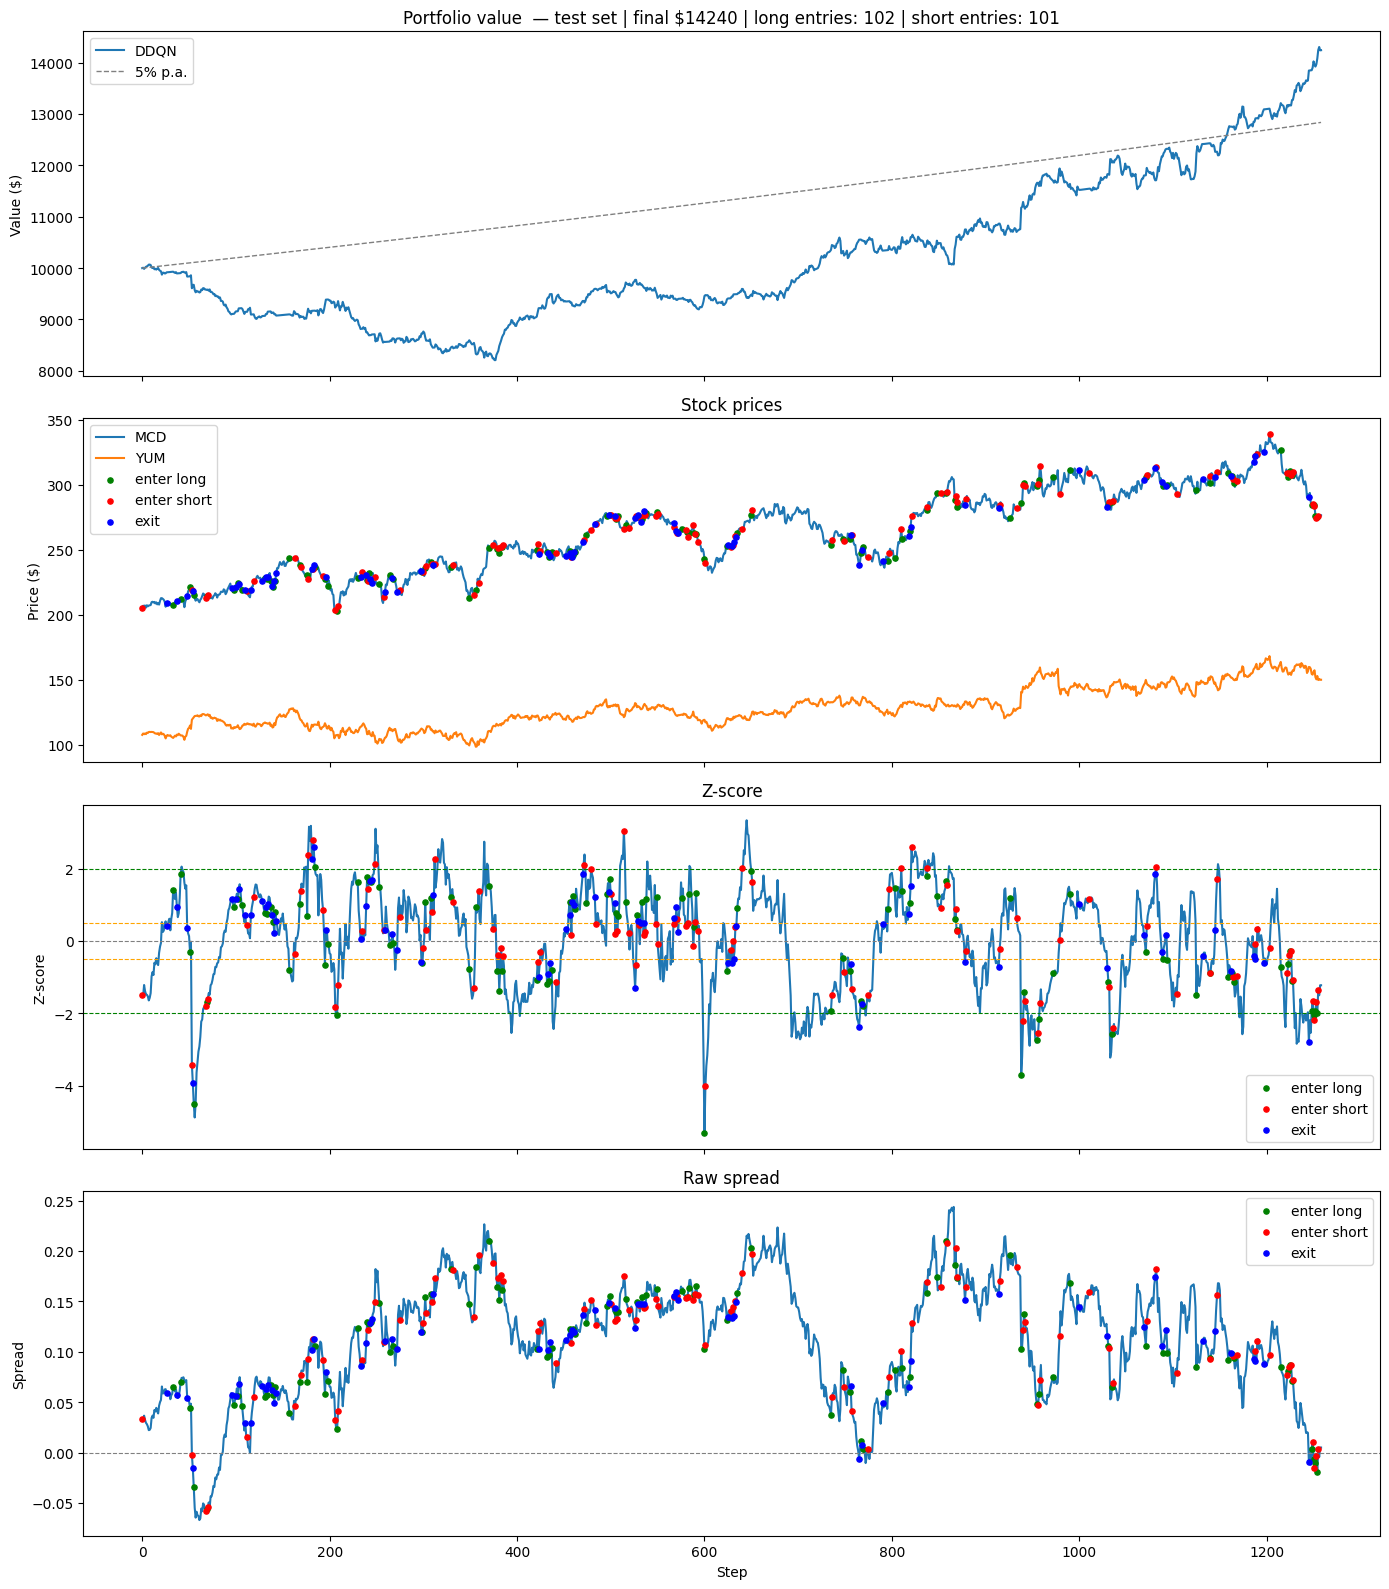

DDQN v2 (3-action) — test set
  Sharpe:            0.303
  Max drawdown:      -18.46%
  Annualised return: 7.33%
  Total return:      42.40%

Cash (5% rf) — test set
  Sharpe:            -75907007.746
  Max drawdown:      0.00%
  Annualised return: 5.00%
  Total return:      27.58%



{'sharpe': np.float64(-75907007.7456248),
 'max_dd': np.float64(0.0),
 'ann_ret': np.float64(0.049959310024009884),
 'tot_ret': np.float64(0.2757874519259019)}

In [12]:
# ── Test-set evaluation ───────────────────────────────────────────────────
res = evaluate(eval_env, agent)

n_long  = len(res["entries_long"])
n_short = len(res["entries_short"])
plot_results(res, title=f"— test set | final ${res['wealth'][-1]:.0f} | long entries: {n_long} | short entries: {n_short}")

metrics(res["wealth"], "DDQN v2 (3-action) — test set")

rf_daily    = (1.05) ** (1/252) - 1
wealth_cash = 10_000 * (1 + rf_daily) ** np.arange(len(res["wealth"]))
metrics(wealth_cash, "Cash (5% rf) — test set")


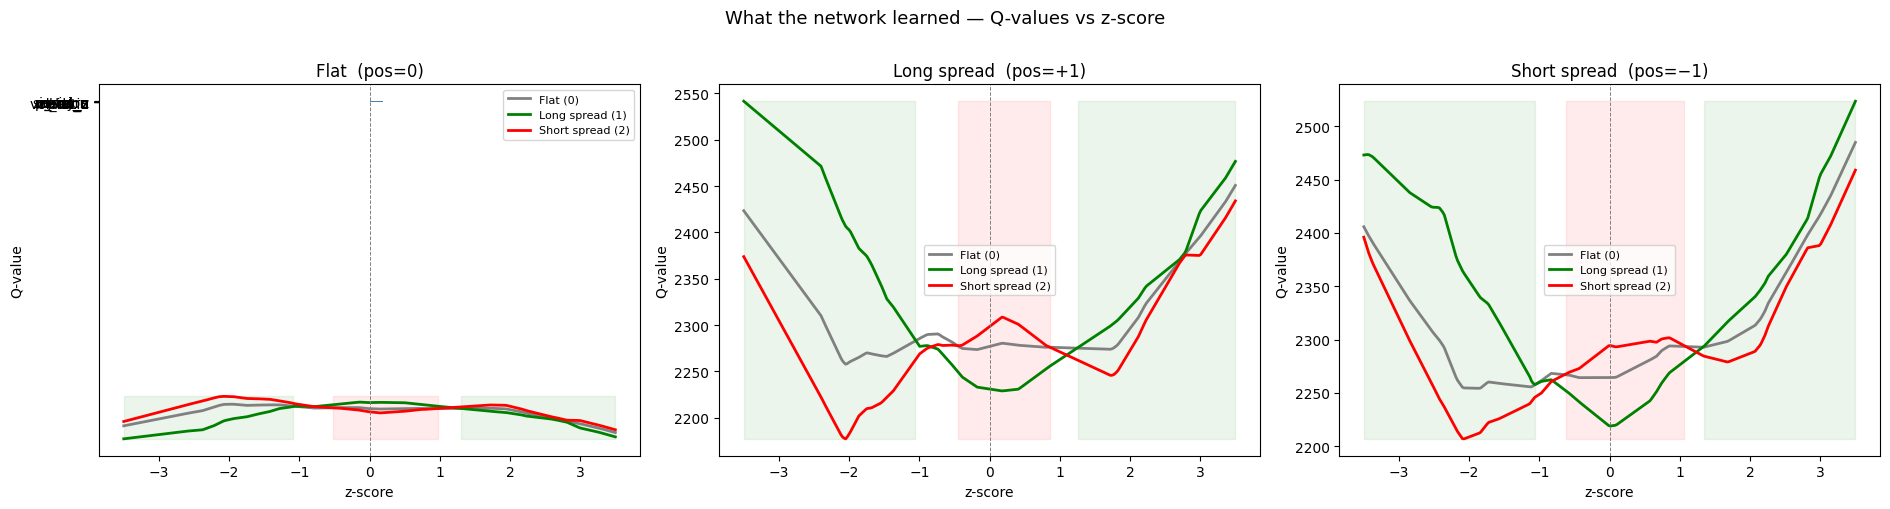

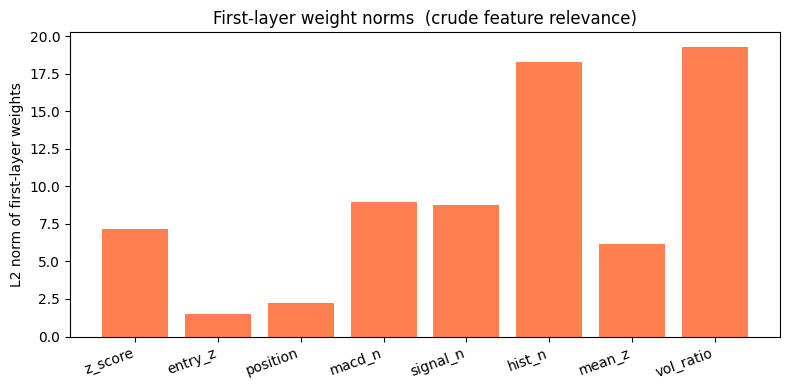

In [14]:
# ── Network interpretation ────────────────────────────────────────────────
FEAT       = ['z_score', 'entry_z', 'position', 'macd_n', 'signal_n', 'hist_n', 'mean_z', 'vol_ratio']
ACT_LABELS = ['Flat (0)', 'Long spread (1)', 'Short spread (2)']
ACT_COLORS = ['gray', 'green', 'red']

# ── 1. Collect test-set observations ─────────────────────────────────────
obs_list = []
_env = eval_env
obs, _ = _env.reset()
obs_list.append(obs.copy())
done = False
while not done:
    action = agent.select_action(obs, deterministic=True)
    obs, _, term, trunc, _ = _env.step(action)
    done = term or trunc
    obs_list.append(obs.copy())
obs_arr  = np.array(obs_list, dtype=np.float32)
mean_obs = obs_arr.mean(0)

# ── 2. Gradient-based feature importance (over all 3 Q-values) ───────────
obs_t  = torch.FloatTensor(obs_arr).requires_grad_(True)
q_vals = agent.q_net(obs_t)               # (T, 3)
q_vals.sum().backward()                   # gradient of sum of all Q-values
grad_imp = obs_t.grad.abs().mean(0).detach().numpy()
grad_imp /= grad_imp.sum()

fig, axes = plt.subplots(1, 3, figsize=(19, 5))

axes[0].barh(FEAT, grad_imp[::-1], color="steelblue")
axes[0].set_xlabel("Mean |∂Q/∂input|  (normalised)")
axes[0].set_title("Feature importance (gradients)")
axes[0].invert_yaxis()

# ── 3. Q-value curves vs z-score  for each of the 3 starting positions ──
z_range = np.linspace(-3.5, 3.5, 300)

for col, (pos_val, pos_label) in enumerate([(0, "Flat  (pos=0)"),
                                             (1, "Long spread  (pos=+1)"),
                                             (-1, "Short spread  (pos=−1)")]):
    sweep       = np.tile(mean_obs, (len(z_range), 1)).copy()
    sweep[:, 0] = z_range    # vary z_score
    sweep[:, 1] = mean_obs[1] if pos_val != 0 else 0.0   # entry_z
    sweep[:, 2] = float(pos_val)

    with torch.no_grad():
        q = agent.q_net(torch.FloatTensor(sweep)).numpy()   # (300, 3)

    ax = axes[col]
    for a_idx, (label, color) in enumerate(zip(ACT_LABELS, ACT_COLORS)):
        ax.plot(z_range, q[:, a_idx], label=label, color=color, lw=2)

    # shade where each non-hold action is best
    best = q.argmax(1)
    ax.fill_between(z_range, q.min(), q.max(),
                    where=(best == 1), alpha=0.08, color="green")
    ax.fill_between(z_range, q.min(), q.max(),
                    where=(best == 2), alpha=0.08, color="red")

    ax.axvline(0, color="gray", lw=0.7, ls="--")
    ax.set_xlabel("z-score")
    ax.set_ylabel("Q-value")
    ax.set_title(pos_label)
    ax.legend(fontsize=8)

plt.suptitle("What the network learned — Q-values vs z-score", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# ── 4. First-layer weight norms ───────────────────────────────────────────
W          = agent.q_net.net[0].weight.detach().numpy()   # (hidden, 8)
feat_norms = np.linalg.norm(W, axis=0)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(FEAT, feat_norms, color="coral")
ax.set_ylabel("L2 norm of first-layer weights")
ax.set_title("First-layer weight norms  (crude feature relevance)")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


In [10]:
agent.save("../models/mcd_yum_ddqn_v2.pt")
print("Model saved.")


Model saved.
